In [87]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import scipy.stats
from typing import List, Tuple, Dict

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [88]:
"""
Load SIS simulation event times output by the Java App into a NumPy array.

- Input directory: `output/sis`
  - `metadata.csv` for parameters (itr, batch_num, c_list, lambda range)
  - `times_XX.txt` where each line is a comma-separated list of event times

- Output array `time`: shape = (len(cList), len(lambdaList), itr), dtype=object
  Each element is a 1D NumPy array of float64 event times for a single run.

Usage:
    from scripts.load_sis_time import load_time_array
    time, axes = load_time_array(output_dir="output/sis", batch_idx=0)
    # time.shape -> (C, L, itr)
    # axes["c_list"], axes["lambda_list"], axes["itr"]
"""

from __future__ import annotations

output_path = os.path.abspath(os.path.join('..', 'output/sis/2RR/z=6/N=5000finalnewlowc'))
# output_path = os.path.abspath(os.path.join('..', 'java-project', 'output'))
if output_path not in sys.path:
    sys.path.append(output_path)

def _read_params(params_path: str) -> Dict[str, str]:
    params = pd.read_csv(params_path)
    network_type = params['networkType'].values[0]
    N = params['N'].values[0]
    k_ave = params['k_ave'].values[0]
    gamma = params['gamma'].values[0]
    rho0 = params['rho0'].values[0]
    tmax = params['tmax'].values[0]
    c_list = params['cList'].values[0]
    edgeNumList = params['edgeNumList'].values[0]
    lambda_values = params['lambdaList'].values[0]
    seed = params['seed'].values[0]
    itr = params['itr'].values[0]
    batchNum = params['batchNum'].values[0]

    try:
        c_list = c_list.split(":")
        c_list = [float(c) for c in c_list]
    except:
        c_list = [float(c_list)]

    edgeNumList = edgeNumList.split(":")
    edgeNumList = [int(edgeNum) for edgeNum in edgeNumList]

    lamb_values = lambda_values.split(":")
    lamb_values = [float(lamb) for lamb in lamb_values]

    return network_type, N, k_ave, gamma, rho0, tmax, seed, itr, batchNum, c_list, lamb_values, edgeNumList


def _read_metadata(meta_path: str = os.path.join(output_path, "metadata.csv")) -> Dict[str, str]:
    """Read key,value style metadata where values may contain commas.

    This parser splits each line at the first comma only.
    Returns a dict of raw string values.
    """
    meta: Dict[str, str] = {}
    with open(meta_path, "r", encoding="utf-8") as f:
        # skip header if present
        header = f.readline()
        if "," not in header:
            # Unexpected; treat as data line
            key, val = header.strip().split(",", 1)
            meta[key.strip()] = val.strip()
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            if "," not in line:
                continue
            key, val = line.split(",", 1)
            meta[key.strip()] = val.strip()
    return meta


def load_batch(output_dir: str, batch_idx: int, isFinal: bool = False) -> Tuple[np.ndarray, np.ndarray]:
    params_path = os.path.join(output_dir, "params.csv")
    if not os.path.exists(params_path):
        raise FileNotFoundError(f"params.csv not found in {output_dir}")

    _, _, _, _, _, _, _, itr, _, c_list, lambda_values, edgeNumList = _read_params(params_path)

    E, C, L = len(edgeNumList), len(c_list), len(lambda_values)
    expected = E * C * L * itr

    times_file = os.path.join(output_dir, f"times_{batch_idx:02d}.txt")
    infected_file = os.path.join(output_dir, f"infected_num_{batch_idx:02d}.txt")
    if not os.path.exists(times_file) or not os.path.exists(infected_file):
        raise FileNotFoundError(f"Missing times or infected file for batch {batch_idx:02d}")

    time = np.empty((E, C, L, itr), dtype=object)
    infected = np.empty((E, C, L, itr), dtype=object)

    # Initialize with empty arrays to avoid uninitialized slots
    for e in range(E):
        for c in range(C):
            for l in range(L):
                for i in range(itr):
                    time[e, c, l, i] = np.array([], dtype=float)
                    infected[e, c, l, i] = np.array([], dtype=int)

    # Iterate paired lines; stop when either file ends
    tcount = icount = 0
    with open(times_file, "r", encoding="utf-8", errors="ignore") as tf, open(infected_file, "r", encoding="utf-8", errors="ignore") as inf:
        while True:
            tline = tf.readline()
            iline = inf.readline()
            if not tline or not iline:
                break
            ts = tline.strip()
            is_ = iline.strip()
            tarr = np.fromstring(ts, sep=",", dtype=float) if ts else np.array([], dtype=float)
            iarr = np.fromstring(is_, sep=",", dtype=int) if is_ else np.array([], dtype=int)

            flat_idx = tcount  # counts paired lines
            if flat_idx >= expected:
                break
            eIdx = flat_idx // (C * L * itr)
            rem = flat_idx % (C * L * itr)
            cIdx = rem // (L * itr)
            rem = rem % (L * itr)
            lIdx = rem // itr
            itIdx = rem % itr
            time[eIdx, cIdx, lIdx, itIdx] = tarr
            infected[eIdx, cIdx, lIdx, itIdx] = iarr
            tcount += 1
            icount += 1

    # If files contain additional lines beyond expected, ignore extras silently.
    # If fewer lines, warn but do not raise.
    if tcount < expected or icount < expected:
        missing = expected - min(tcount, icount)
        print(
            f"[WARN] Batch {batch_idx:02d}: filled {min(tcount, icount)} / {expected} runs; "
            f"{missing} missing. Unfilled slots remain empty arrays.")

    if not isFinal:
        return time, infected
    else:
        return time[-1], infected[-1]

def load(path: str = output_path, max_file_num: int = 1e5, isFinal: bool = False) -> Tuple[np.ndarray, np.ndarray, Dict[str, object]]:
    network_type, N, k_ave, gamma, rho0, tmax, seed, itr, batchNum, c_list, lamb_values, edgeNumList = _read_params(os.path.join(path, "params.csv"))

    valid_batch_idx = []
    valid_file_num = 0

    for batch_idx in range(batchNum):
        if os.path.exists(os.path.join(path, f"times_{batch_idx:02d}.txt")) and os.path.exists(os.path.join(path, f"infected_num_{batch_idx:02d}.txt")):
            print(f"idx: {batch_idx}, {valid_file_num}th file is found")
            valid_batch_idx.append(batch_idx)
            valid_file_num += 1
            if valid_file_num >= max_file_num:
                break

    total_itr = len(valid_batch_idx) * itr
    shape = (len(edgeNumList), len(c_list), len(lamb_values), total_itr)
    times_all = np.zeros(shape, dtype=object)
    infected_num_all = np.zeros(shape, dtype=object)  # 修正: dtype=object

    print("")
    print(f"Lets load {valid_file_num} files!")

    for batch_idx in valid_batch_idx:
        print(f" --> Loading {batch_idx}th file...")
        times, infected_num = load_batch(path, batch_idx, isFinal)
        times_all[:, :, :, batch_idx * itr : (batch_idx + 1) * itr] = times
        infected_num_all[:, :, :, batch_idx * itr : (batch_idx + 1) * itr] = infected_num

    axes = {
        "network_type": network_type,
        "N": N,
        "k_ave": k_ave,
        "gamma": gamma,
        "rho0": rho0,
        "tmax": tmax,
        "seed": seed,
        "total_itr": total_itr,
        "c_list": c_list,
        "edgeNumList": edgeNumList,
        "lamb_values": lamb_values,
    }

    return times_all, infected_num_all, axes

In [89]:
# y(Theta)を計算する関数
def y_SIS(deg_list, pk, lamb, gamma, Theta, c=0):
    # 平均次数 <k> = Σ k*p(k)
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -Theta

    y = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        y += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    
    y /= k_ave
    y -= Theta
    return y

# y'(Theta) = dy/dTheta を計算する関数
def dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c=0.0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -1.0
    dy = 0.0
    for k, p in zip(deg_list, pk):
        B = gamma + lamb * k * Theta * (1.0 + c * k * Theta)  # 正しい分母
        if B == 0:
            return np.nan
        fprime = (lamb * gamma * k * (1.0 + 2.0 * c * k * Theta)) / (B ** 2)
        dy += k * p * fprime
    dy /= k_ave
    dy -= 1.0
    return dy


# ニュートン法を実装した関数
def newton_method(deg_list, pk, lamb, gamma, Theta_initial=0.9, tolerance=1e-16, max_iter=100, c=0):
    """
    ニュートン法を用いて y_SIS(Theta) = 0 となるThetaを探す
    """
    Theta = Theta_initial
    for i in range(max_iter):
        y_val = y_SIS(deg_list, pk, lamb, gamma, Theta, c)
        
        # yが十分に0に近ければ終了
        if abs(y_val) < tolerance:
            return Theta

        dy_val = dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c)

        # 導関数が0に近く、更新が発散しそうな場合は終了
        if abs(dy_val) < 1e-10:
            # print(f"Warning: Derivative is too small at lambda={lamb}, Theta={Theta}. Stopping.")
            return Theta

        # ニュートン法の更新式
        Theta_new = Theta - y_val / dy_val
        
        # 更新量が十分に小さくなれば終了
        if abs(Theta_new - Theta) < tolerance:
            return Theta_new
            
        Theta = Theta_new
        
    # print(f"Warning: Newton's method did not converge for lambda={lamb} within {max_iter} iterations.")
    return Theta

def theta_to_I(deg_list, pk, lamb, gamma, Theta, c=0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return 0
    I = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        I += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    I /= k_ave
    return I

def theta_symbolic_RR_numeric(lamb: float, K: float, gamma: float, c: float) -> float:
    """
    RR（正則）ネットワークの閉形式解を用いて Theta(λ) を数値的に返す。
    - c=0 のとき: Theta = max(0, 1 - gamma/(lambda*K))
    - c>0 のとき: 2次方程式の正の根を使用。
    物理的制約に合わせて [0,1] にクリップする。
    """
    if lamb <= 0:
        return 0.0
    if c == 0:
        theta = 1.0 - gamma / (lamb * K)
        return float(np.clip(theta, 0.0, 1.0))
    a = c * K
    b = 1.0 - c * K
    c0 = gamma / (lamb * K) - 1.0
    D = b * b - 4.0 * a * c0
    if D < 0:
        return 0.0
    theta = (-b + np.sqrt(D)) / (2.0 * a)
    return float(np.clip(theta, 0.0, 1.0))

In [90]:
def load_batch_modified(output_dir: str, batch_idx: int, isFinal: bool = False) -> Tuple[np.ndarray, np.ndarray]:
    params_path = os.path.join(output_dir, "params.csv")
    if not os.path.exists(params_path):
        raise FileNotFoundError(f"params.csv not found in {output_dir}")

    _, _, _, _, _, _, _, itr, _, c_list, lambda_values, edgeNumList = _read_params(params_path)

    E, C, L = len(edgeNumList), len(c_list), len(lambda_values)
    expected = E * C * L * itr

    times_file = os.path.join(output_dir, f"times_{batch_idx:02d}.txt")
    infected_file = os.path.join(output_dir, f"infected_num_{batch_idx:02d}.txt")
    if not os.path.exists(times_file) or not os.path.exists(infected_file):
        raise FileNotFoundError(f"Missing times or infected file for batch {batch_idx:02d}")

    time = np.empty((E, C, L, itr), dtype=object)
    infected = np.empty((E, C, L, itr), dtype=object)

    # Initialize with empty arrays to avoid uninitialized slots
    for e in range(E):
        for c in range(C):
            for l in range(L):
                for i in range(itr):
                    time[e, c, l, i] = np.array([], dtype=float)
                    infected[e, c, l, i] = np.array([], dtype=int)

    # Read all lines first
    with open(times_file, "r", encoding="utf-8", errors="ignore") as tf, open(infected_file, "r", encoding="utf-8", errors="ignore") as inf:
        tlines = tf.readlines()
        ilines = inf.readlines()

    # If isFinal=True, only process the last 'expected' lines
    if isFinal:
        if len(tlines) < expected or len(ilines) < expected:
            print(f"[WARN] Batch {batch_idx:02d}: Not enough lines for final batch. "
                  f"Available: {min(len(tlines), len(ilines))}, Expected: {expected}")
            lines_to_process = min(len(tlines), len(ilines))
        else:
            lines_to_process = expected
        # Take only the last 'lines_to_process' lines
        tlines = tlines[-lines_to_process:]
        ilines = ilines[-lines_to_process:]

    # Process the lines
    tcount = icount = 0
    for tline, iline in zip(tlines, ilines):
        ts = tline.strip()
        is_ = iline.strip()
        tarr = np.fromstring(ts, sep=",", dtype=float) if ts else np.array([], dtype=float)
        iarr = np.fromstring(is_, sep=",", dtype=int) if is_ else np.array([], dtype=int)

        flat_idx = tcount  # counts paired lines
        if flat_idx >= expected:
            break
        eIdx = flat_idx // (C * L * itr)
        rem = flat_idx % (C * L * itr)
        cIdx = rem // (L * itr)
        rem = rem % (L * itr)
        lIdx = rem // itr
        itIdx = rem % itr
        time[eIdx, cIdx, lIdx, itIdx] = tarr
        infected[eIdx, cIdx, lIdx, itIdx] = iarr
        tcount += 1
        icount += 1

    # If files contain additional lines beyond expected, ignore extras silently.
    # If fewer lines, warn but do not raise.
    if tcount < expected or icount < expected:
        missing = expected - min(tcount, icount)
        print(
            f"[WARN] Batch {batch_idx:02d}: filled {min(tcount, icount)} / {expected} runs; "
            f"{missing} missing. Unfilled slots remain empty arrays.")

    if not isFinal:
        return time, infected
    else:
        return time[-1], infected[-1]


In [91]:
times_all, infected_num_all, axes = load()
meta = _read_metadata()
network_type = axes["network_type"]
N = axes["N"]
k_ave = axes["k_ave"]
gamma = axes["gamma"]
rho0 = axes["rho0"]
tmax = axes["tmax"]
seed = axes["seed"]
total_itr = axes["total_itr"]
c_list = axes["c_list"]
edgeNumList = axes["edgeNumList"]
lamb_values = axes["lamb_values"]

idx: 0, 0th file is found
idx: 1, 1th file is found
idx: 2, 2th file is found
idx: 3, 3th file is found
idx: 4, 4th file is found
idx: 5, 5th file is found
idx: 6, 6th file is found
idx: 7, 7th file is found
idx: 8, 8th file is found
idx: 9, 9th file is found
idx: 10, 10th file is found
idx: 11, 11th file is found
idx: 12, 12th file is found
idx: 13, 13th file is found
idx: 14, 14th file is found
idx: 15, 15th file is found
idx: 16, 16th file is found
idx: 17, 17th file is found
idx: 18, 18th file is found
idx: 19, 19th file is found
idx: 20, 20th file is found
idx: 21, 21th file is found
idx: 22, 22th file is found
idx: 23, 23th file is found
idx: 24, 24th file is found
idx: 25, 25th file is found
idx: 26, 26th file is found
idx: 27, 27th file is found
idx: 28, 28th file is found
idx: 29, 29th file is found
idx: 30, 30th file is found
idx: 31, 31th file is found
idx: 32, 32th file is found
idx: 33, 33th file is found
idx: 34, 34th file is found
idx: 35, 35th file is found
idx: 36, 36t

In [92]:
print("==== shape ====")
print(times_all.shape)
print(infected_num_all.shape)

print("")
print("==== params ====")
print(f"network_type: {network_type}")
print(f"N: {N}")
print(f"k_ave: {k_ave}")
print(f"gamma: {gamma}")
print(f"rho0: {rho0}")
print(f"tmax: {tmax}")
print(f"seed: {seed}")
print(f"total_itr: {total_itr}")

print("")
print("==== meta data ====")
for key, value in meta.items():
    print(f"{key}: {value}")

==== shape ====
(4, 2, 41, 200)
(4, 2, 41, 200)

==== params ====
network_type: 2RR
N: 5000
k_ave: 6
gamma: 1.0
rho0: 0.5
tmax: 600.0
seed: 0.0
total_itr: 200

==== meta data ====
start_time: 2025-09-13 02:54:11
end_time: 2025-09-13 04:13:48
duration_seconds: 4777.805
network_type: 2RR
runs_per_batch: 410
total_runs: 16400
seed_base: 0
os_name: Mac OS X
os_version: 15.3.1
java_version: 24.0.2
java_vendor: Homebrew
cpu_cores: 10
total_memory_mb: 3762
max_memory_mb: 4096


In [93]:
test_lamb_idx_list = [0, 10, 20, 30]

lamb_idx_list = []
for lamb_idx in test_lamb_idx_list:
    if lamb_idx < len(lamb_values):
        lamb_idx_list.append(lamb_idx)

lamb_idx_list = np.array(lamb_idx_list)


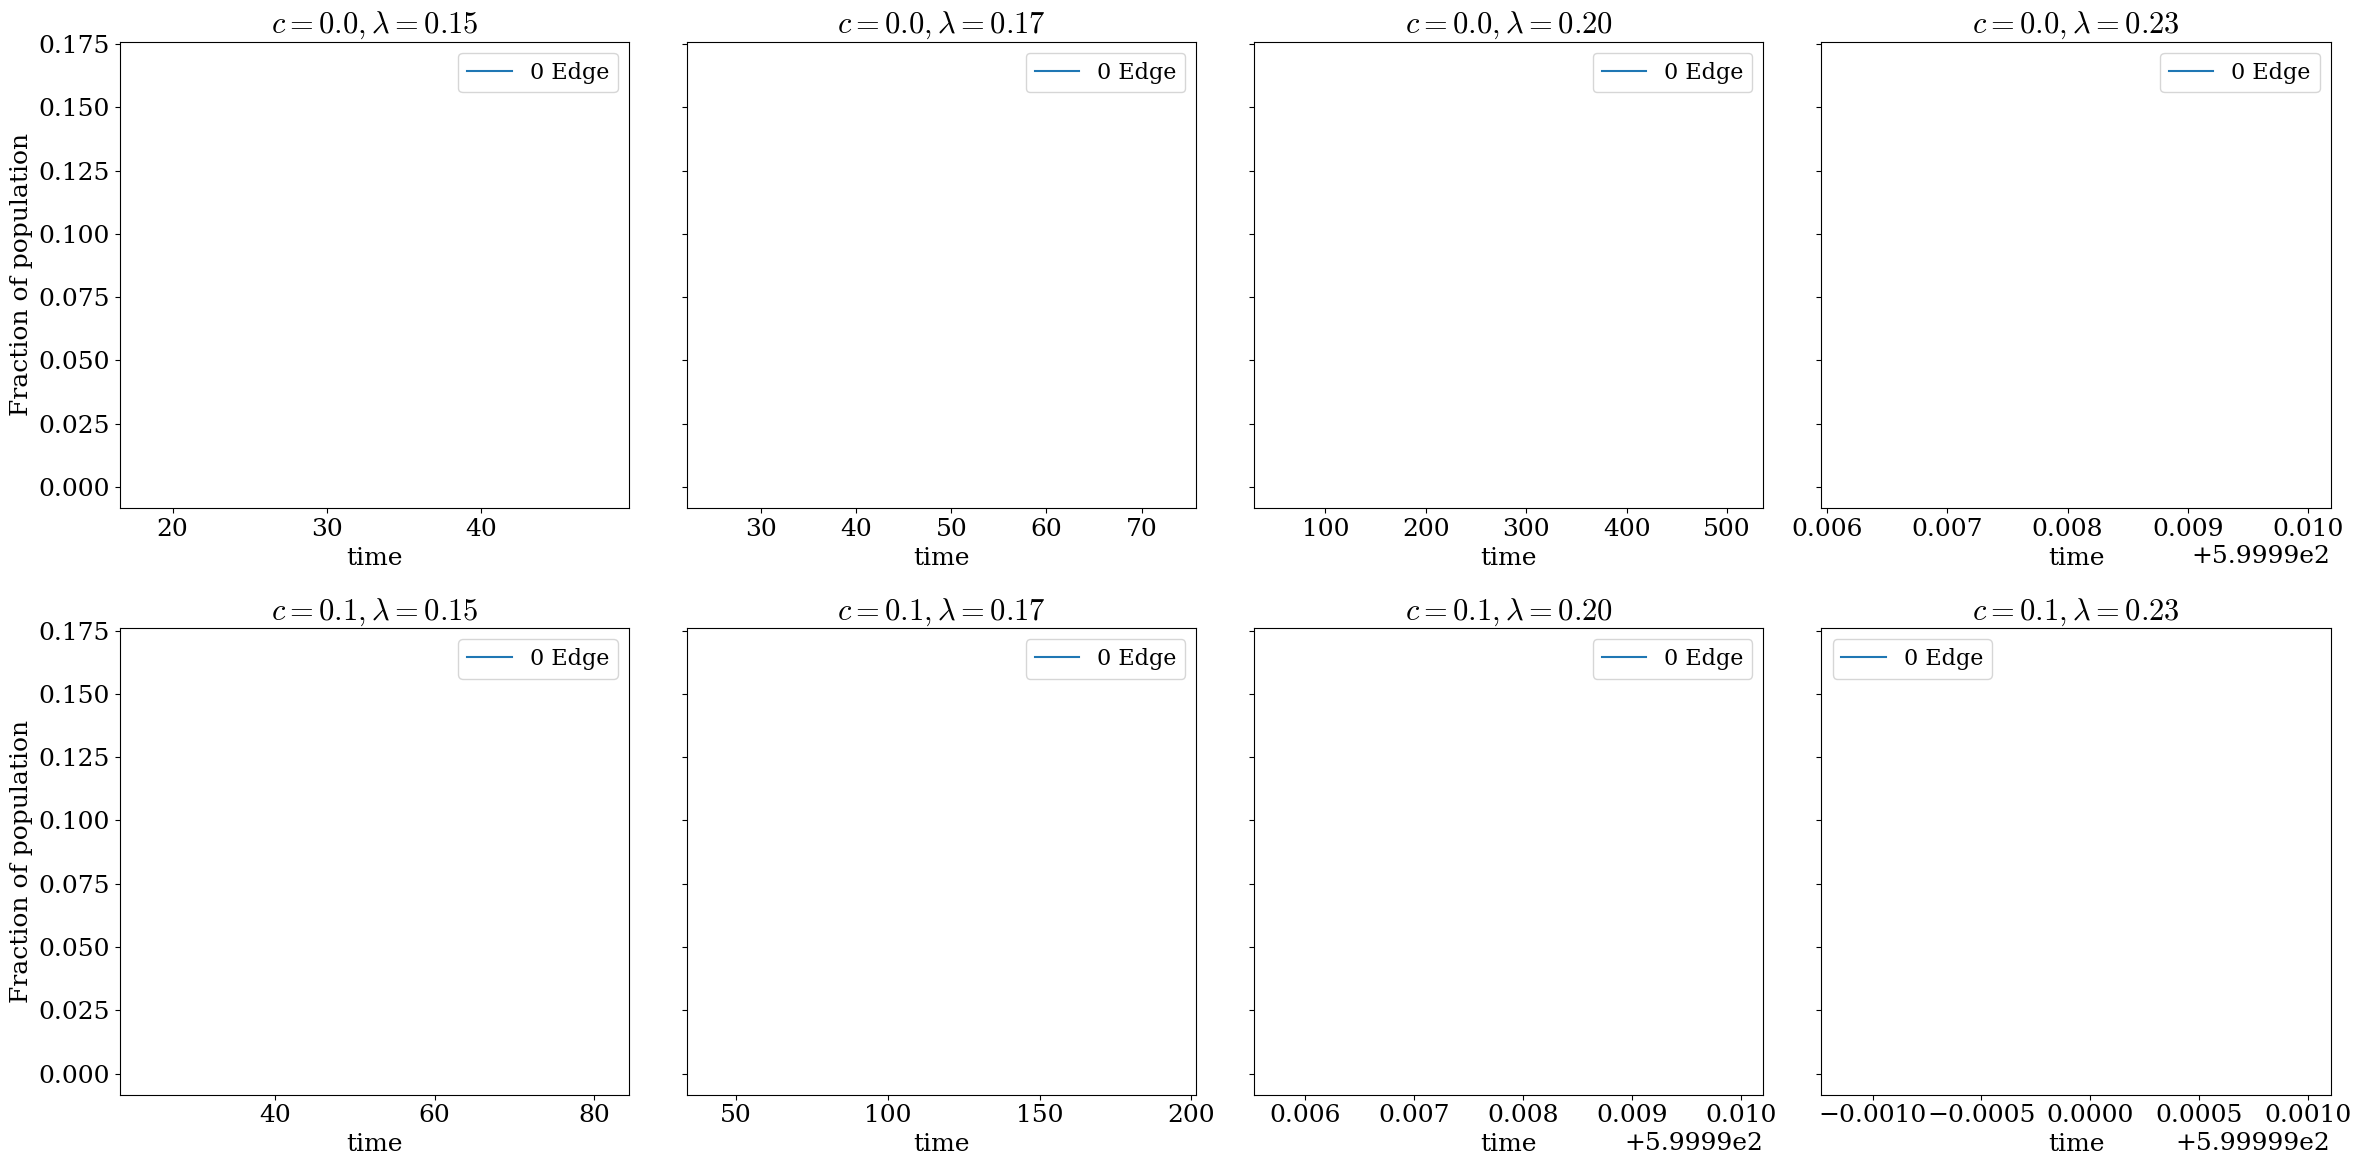

In [94]:
fig, axes_plot = plt.subplots(len(c_list), len(lamb_idx_list), figsize=(6 * len(lamb_idx_list), 6 * len(c_list)), sharey=True)
edge_idx_list = [0]

for c_idx, c in enumerate(c_list):
    for l_idx, lamb_idx in enumerate(lamb_idx_list):
        v_num = 0
        lamb = lamb_values[lamb_idx]
        for e_idx, edge_idx in enumerate(edge_idx_list):
            edge_num = edgeNumList[edge_idx]
            axes_plot[c_idx, l_idx].plot([], [], color=colors[e_idx], label=f"{edge_num} Edge")
            for itr_idx in range(total_itr):
                I = infected_num_all[edge_idx, c_idx, lamb_idx, itr_idx]
                t = times_all[edge_idx, c_idx, lamb_idx, itr_idx]
                axes_plot[c_idx, l_idx].plot(t, I/(2*N), color=colors[e_idx], alpha=0.5)
                axes_plot[c_idx, l_idx].legend()
        axes_plot[c_idx, l_idx].set_title(rf"$c={c}, \lambda={lamb:.2f}$")
        axes_plot[c_idx, l_idx].set_xlabel("time")
        # axes_plot[c_idx, l_idx].set_yscale("log")
        if l_idx == 0:
            axes_plot[c_idx, l_idx].set_ylabel(r"Fraction of population")

fig.tight_layout()
plt.show()


In [95]:
threshold = 0

last_I = np.zeros((len(edgeNumList), len(c_list), len(lamb_values), total_itr))
valid_last_I = np.zeros((len(edgeNumList), len(c_list), len(lamb_values)))
valid_num = np.zeros((len(edgeNumList), len(c_list), len(lamb_values)))
for edge_idx in range(len(edgeNumList)):
    for c_idx in range(len(c_list)):
        for lamb_idx in range(len(lamb_values)):
            valid = []
            non_valid = []
            for itr_idx in range(total_itr):
                last_I[edge_idx, c_idx, lamb_idx, itr_idx] = infected_num_all[edge_idx, c_idx, lamb_idx, itr_idx][0]
                if last_I[edge_idx, c_idx, lamb_idx, itr_idx] > threshold:
                    valid.append(last_I[edge_idx, c_idx, lamb_idx, itr_idx])
                    valid_num[edge_idx, c_idx, lamb_idx] += 1
                else:
                    non_valid.append(last_I[edge_idx, c_idx, lamb_idx, itr_idx])
            if len(valid) > 0:
                valid_last_I[edge_idx, c_idx, lamb_idx] = np.mean(valid)
            else:
                valid_last_I[edge_idx, c_idx, lamb_idx] = np.mean(non_valid)


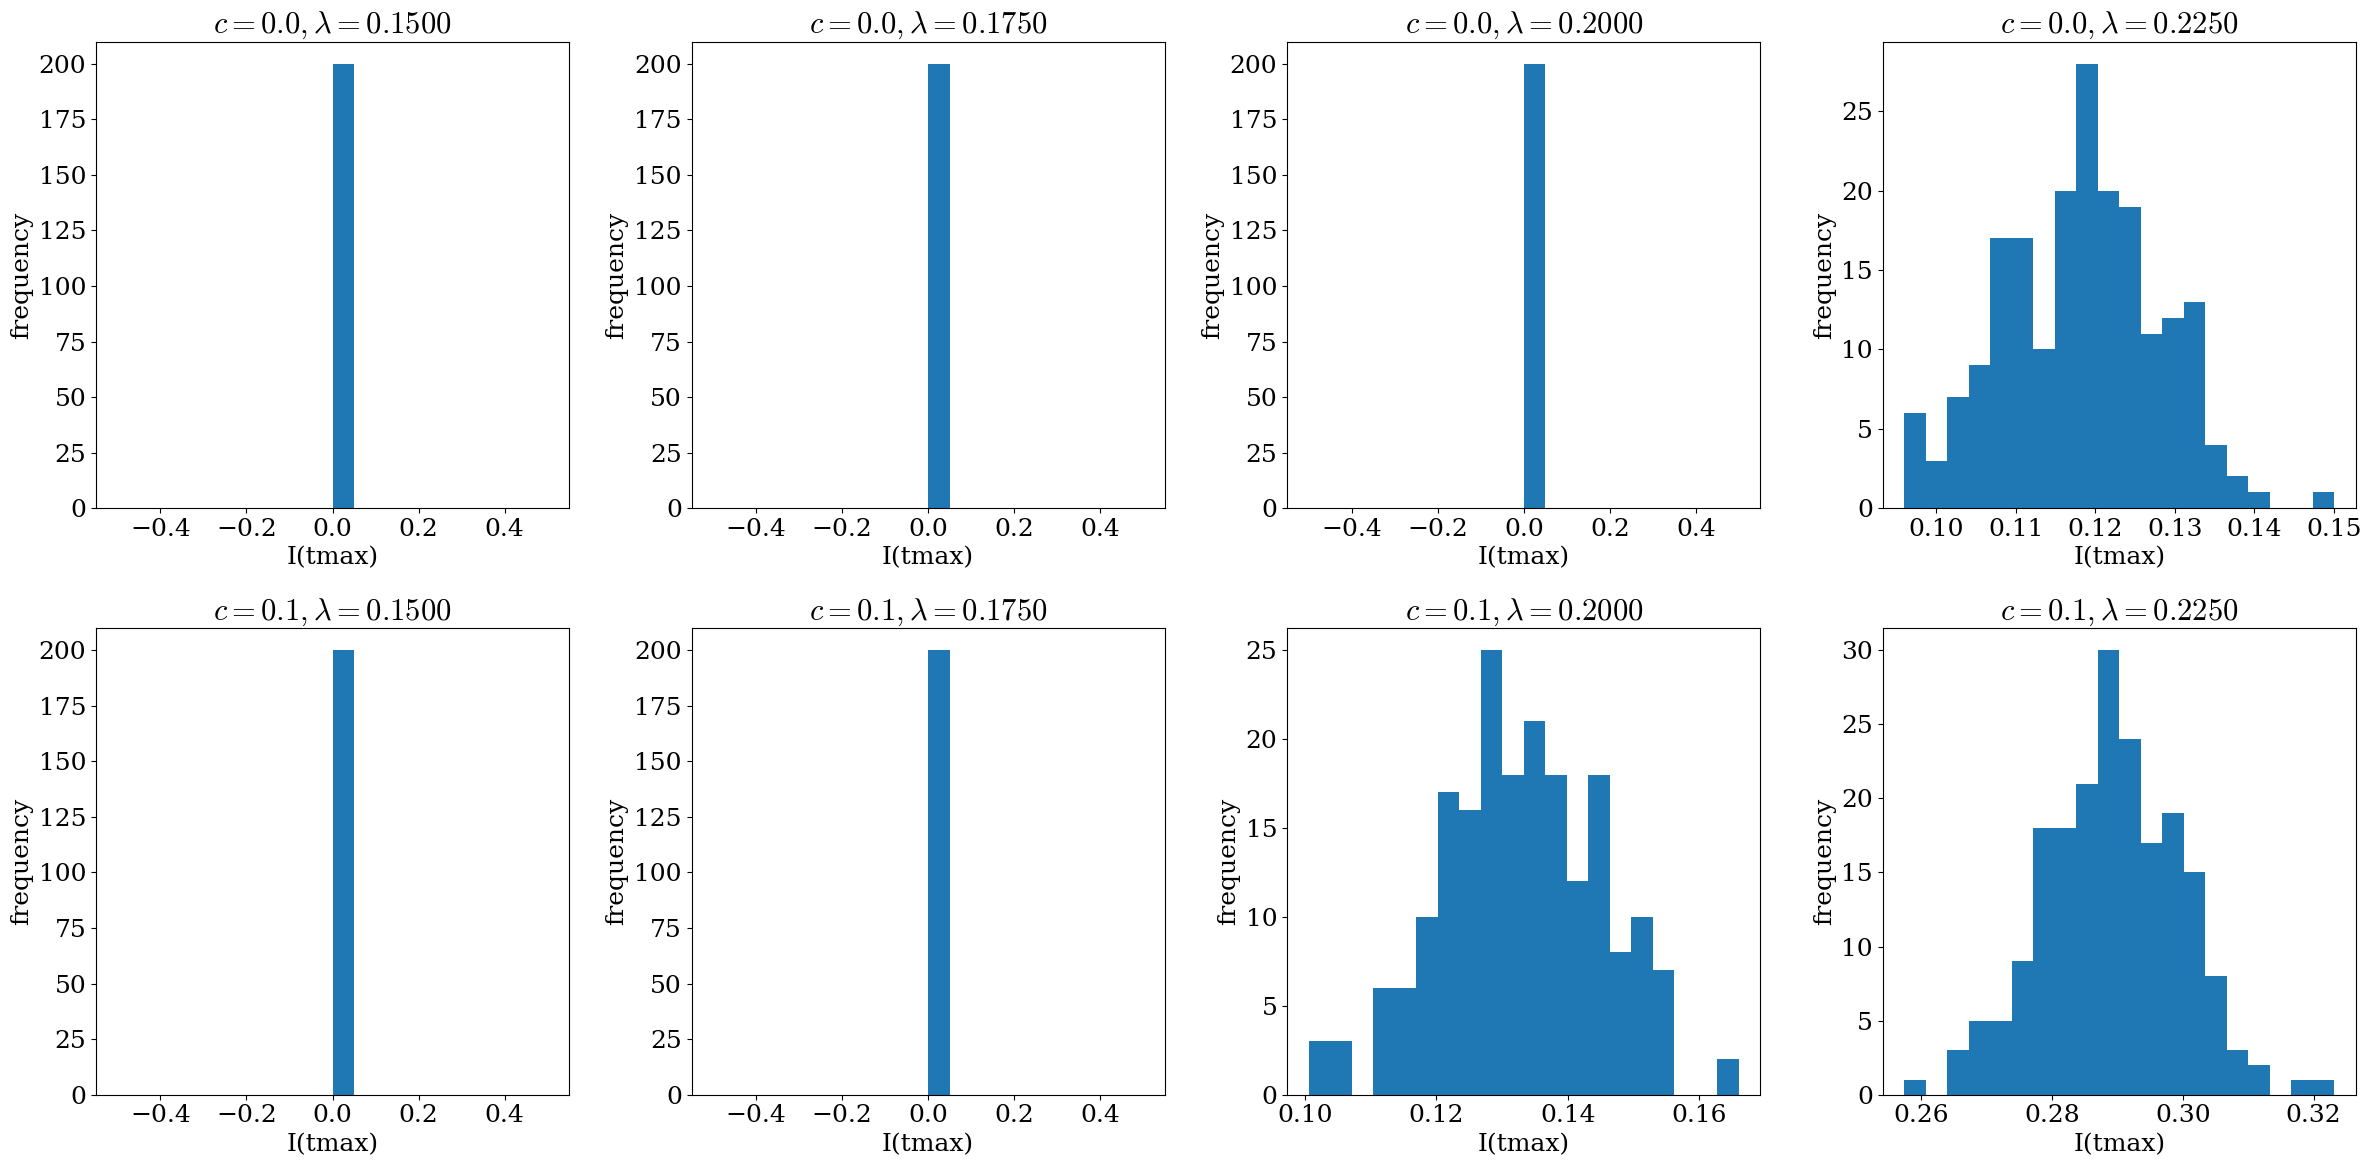

In [96]:
fig, axes = plt.subplots(len(c_list), len(lamb_idx_list), figsize=(6 * len(lamb_idx_list), 6 * len(c_list)))

e_idx = 2
for c_idx, c in enumerate(c_list):
    for l_idx, lamb_idx in enumerate(lamb_idx_list):
        lamb = lamb_values[lamb_idx]
        axes[c_idx, l_idx].hist(last_I[e_idx, c_idx, lamb_idx, :]/(2.0 * N), bins=20)
        axes[c_idx, l_idx].set_title(rf"$c={c}, \lambda={lamb:.4f}$")
        axes[c_idx, l_idx].set_xlabel("I(tmax)")
        axes[c_idx, l_idx].set_ylabel("frequency")

fig.tight_layout()

plt.show()

In [97]:
# lamb_values_for_theory = np.linspace(np.min(lamb_values), np.max(lamb_values), 1000)
# theta_all = np.zeros((len(c_list), len(lamb_values_for_theory)))

# for cidx, c in enumerate(c_list):
#     theta_results = []

#     # 各lambdaについてニュートン法でThetaを解く
#     for lamb in lamb_values_for_theory:
#         if network_type == "RR":
#             # 次数のリスト
#             deg_list = [k_ave]
#             pk = np.array([1.0])
#             solution = theta_symbolic_RR_numeric(lamb, k_ave, gamma, c)

#         elif network_type == "ER":
#             # 次数のリスト (ポアソン分布が意味を持つ範囲)
#             # 平均の3倍+10程度あれば十分
#             deg_list = np.arange(0, int(k_ave * 3) + 10)

#             # 次数分布 p(k) を計算 (ポアソン分布)
#             pk = scipy.stats.poisson.pmf(deg_list, k_ave)
#             solution = newton_method(deg_list, pk, lamb, gamma, c=c)

#         # elif network_type == "SF":
#         #     deg_list = np.arange(1, 1000)

#         #     C = (2 - kappa) * k_ave
#         #     pk = C * deg_list ** (- kappa)

#         else:
#             raise ValueError(f"Invalid network type: {network_type}")

#         # 初期値は重要。ここでは前のステップの結果を流用すると収束しやすいが、簡単のため固定値から始める
#         # 問題によってはTheta=0も根になる（自明な解）ため、0以外の初期値を選ぶ
#         # 物理的に意味のある解は [0,1] に収める
#         solution = float(np.clip(solution, 0.0, 1.0))
#         theta_results.append(solution)
#         # print(f"{lamb:.4f}, {solution:.8f}")

#     theta_all[cidx, :] = theta_results

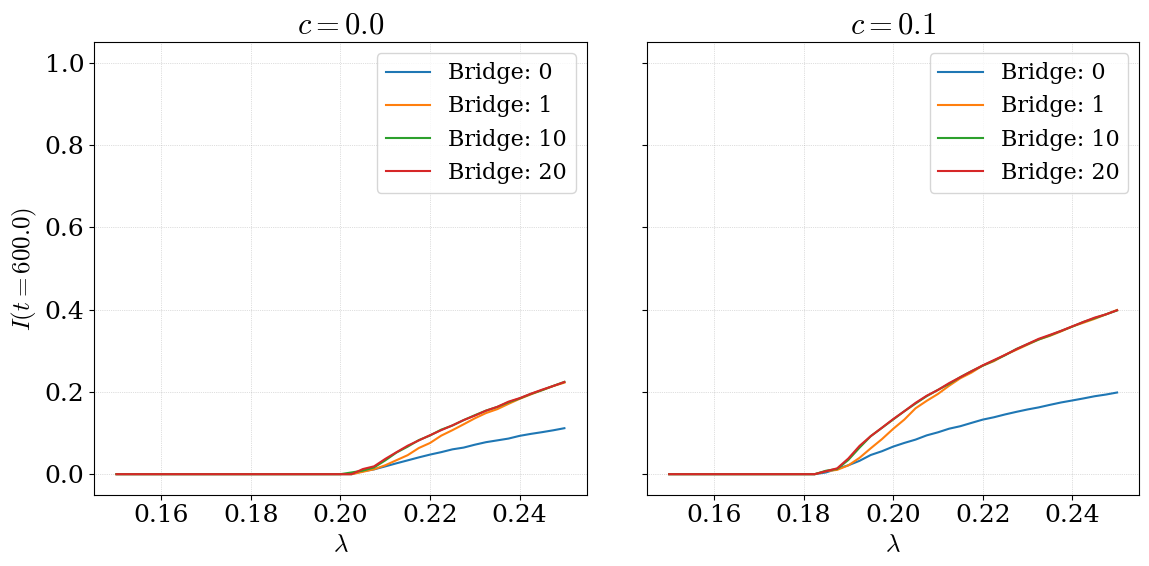

In [98]:
fig, axes = plt.subplots(1, len(c_list), figsize=(6 * len(c_list), 6), sharey=True)

delta = 0.05

for c_idx, c in enumerate(c_list):
    # to_Is = np.zeros(len(lamb_values_for_theory))
    # for lamb_idx, lamb in enumerate(lamb_values_for_theory):
    #     to_I = theta_to_I(deg_list, pk, lamb, gamma, theta_all[c_idx, lamb_idx], c=c)
    #     to_Is[lamb_idx] = to_I
    # axes[c_idx].plot(lamb_values_for_theory, to_Is, color=colors[0], label="Theory", linestyle="--", linewidth=0.5)

    for e_idx in range(len(edgeNumList)):
        edge_num = edgeNumList[e_idx]
        valid_mean_I = valid_last_I[e_idx, c_idx, :]
        axes[c_idx].plot(lamb_values, valid_mean_I/(2 * N), label=rf"Bridge: {edge_num}", color=colors[e_idx])
        # axes[c_idx].plot(lamb_values, valid_mean_I/(2 * N), label=f"edge={edge_num}", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])

    axes[c_idx].legend()
    axes[c_idx].grid(True, linestyle=":", alpha=0.5)
    axes[c_idx].set_title(rf"$c={c}$")
    axes[c_idx].set_xlabel(r"$\lambda$")
    if c_idx == 0:
        axes[c_idx].set_ylabel(rf"$I(t={tmax})$")
    # axes[c_idx].set_xlim(0.10, 0.11)
    axes[c_idx].set_ylim(0-delta, 1+delta)

# fig.suptitle(rf"Network$: {network_type}, N={N}, \left<k\right>={k_ave}, \rho_0={rho0}, $tmax$={tmax}$")
fig.tight_layout()

plt.show()

In [99]:
output_path = os.path.abspath(os.path.join('..', 'output/sis/2RR/z=6/N=5000finalnew'))
times_all2, infected_num_all2, axes2 = load(path=output_path)
meta2 = _read_metadata()
network_type2 = axes2["network_type"]
N2 = axes2["N"]
k_ave2 = axes2["k_ave"]
gamma2 = axes2["gamma"]
rho02 = axes2["rho0"]
tmax2 = axes2["tmax"]
seed2 = axes2["seed"]
total_itr2 = axes2["total_itr"]
c_list2 = axes2["c_list"]
edgeNumList2 = axes2["edgeNumList"]
lamb_values2 = axes2["lamb_values"]

idx: 0, 0th file is found
idx: 1, 1th file is found
idx: 2, 2th file is found
idx: 3, 3th file is found
idx: 4, 4th file is found
idx: 5, 5th file is found
idx: 6, 6th file is found
idx: 7, 7th file is found
idx: 8, 8th file is found
idx: 9, 9th file is found
idx: 10, 10th file is found
idx: 11, 11th file is found
idx: 12, 12th file is found
idx: 13, 13th file is found
idx: 14, 14th file is found
idx: 15, 15th file is found
idx: 16, 16th file is found
idx: 17, 17th file is found
idx: 18, 18th file is found
idx: 19, 19th file is found
idx: 20, 20th file is found
idx: 21, 21th file is found
idx: 22, 22th file is found
idx: 23, 23th file is found
idx: 24, 24th file is found
idx: 25, 25th file is found
idx: 26, 26th file is found
idx: 27, 27th file is found
idx: 28, 28th file is found
idx: 29, 29th file is found
idx: 30, 30th file is found
idx: 31, 31th file is found
idx: 32, 32th file is found
idx: 33, 33th file is found
idx: 34, 34th file is found
idx: 35, 35th file is found
idx: 36, 36t

In [100]:
print("==== shape ====")
print(times_all2.shape)
print(infected_num_all2.shape)

print("")
print("==== params ====")
print(f"network_type: {network_type2}")
print(f"N: {N2}")
print(f"k_ave: {k_ave2}")
print(f"gamma: {gamma2}")
print(f"rho0: {rho02}")
print(f"tmax: {tmax2}")
print(f"seed: {seed2}")
print(f"total_itr: {total_itr2}")

print("")
print("==== meta data ====")
for key, value in meta2.items():
    print(f"{key}: {value}")

==== shape ====
(4, 2, 121, 200)
(4, 2, 121, 200)

==== params ====
network_type: 2RR
N: 5000
k_ave: 6
gamma: 1.0
rho0: 0.5
tmax: 600.0
seed: 0.0
total_itr: 200

==== meta data ====
start_time: 2025-09-13 02:54:11
end_time: 2025-09-13 04:13:48
duration_seconds: 4777.805
network_type: 2RR
runs_per_batch: 410
total_runs: 16400
seed_base: 0
os_name: Mac OS X
os_version: 15.3.1
java_version: 24.0.2
java_vendor: Homebrew
cpu_cores: 10
total_memory_mb: 3762
max_memory_mb: 4096


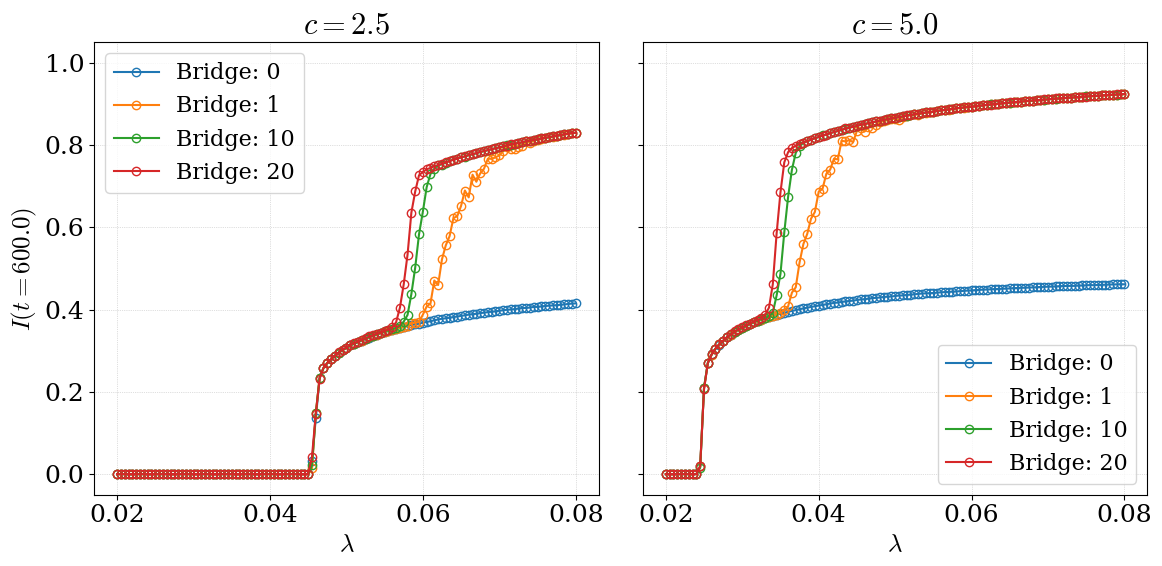

In [101]:
last_I2 = np.zeros((len(edgeNumList2), len(c_list2), len(lamb_values2), total_itr2))
valid_last_I2 = np.zeros((len(edgeNumList2), len(c_list2), len(lamb_values2)))
valid_num2 = np.zeros((len(edgeNumList2), len(c_list2), len(lamb_values2)))

for edge_idx in range(len(edgeNumList2)):
    for c_idx in range(len(c_list2)):
        for lamb_idx in range(len(lamb_values2)):
            valid = []
            non_valid = []
            for itr_idx in range(total_itr2):
                last_I2[edge_idx, c_idx, lamb_idx, itr_idx] = infected_num_all2[edge_idx, c_idx, lamb_idx, itr_idx][0]
                if last_I2[edge_idx, c_idx, lamb_idx, itr_idx] > threshold:
                    valid.append(last_I2[edge_idx, c_idx, lamb_idx, itr_idx])
                    valid_num2[edge_idx, c_idx, lamb_idx] += 1
                else:
                    non_valid.append(last_I2[edge_idx, c_idx, lamb_idx, itr_idx])
            if len(valid) > 0:
                valid_last_I2[edge_idx, c_idx, lamb_idx] = np.mean(valid)
            else:
                valid_last_I2[edge_idx, c_idx, lamb_idx] = np.mean(non_valid)


fig, axes = plt.subplots(1, len(c_list2), figsize=(6 * len(c_list2), 6), sharey=True)

for c_idx, c in enumerate(c_list2):

    for e_idx in range(len(edgeNumList)):
        edge_num = edgeNumList[e_idx]
        valid_mean_I2 = valid_last_I2[e_idx, c_idx, :]
        axes[c_idx].plot(lamb_values2, valid_mean_I2/(2 * N2), label=rf"Bridge: {edge_num}", linestyle="-", color=colors[e_idx], marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])
        # axes[c_idx].plot(lamb_values, valid_mean_I/(2 * N), label=f"edge={edge_num}", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])

    axes[c_idx].legend()
    axes[c_idx].grid(True, linestyle=":", alpha=0.5)
    axes[c_idx].set_title(rf"$c={c}$")
    axes[c_idx].set_xlabel(r"$\lambda$")
    if c_idx == 0:
        axes[c_idx].set_ylabel(rf"$I(t={tmax})$")
    # axes[c_idx].set_xlim(0.10, 0.11)
    axes[c_idx].set_ylim(0-delta, 1+delta)

# fig.suptitle(rf"Network$: {network_type}, N={N}, \left<k\right>={k_ave}, \rho_0={rho0}, $tmax$={tmax}$")
fig.tight_layout()

plt.show()

In [102]:
rho0List_ame = [0.001, 1.0]
c_list_ame = [0.0, 0.1]
arr = np.zeros((len(rho0List_ame), len(c_list_ame)), dtype=object)
lambda_values_ame = np.zeros((len(rho0List_ame), len(c_list_ame)), dtype=object)
I_ame = np.zeros((len(rho0List_ame), len(c_list_ame)), dtype=object)

base_ame_path = "../ame/"
for r_idx, rho0 in enumerate(rho0List_ame):
    str_rho0 = str(rho0)
    for c_idx, c in enumerate(c_list_ame):
        str_c = str(c)
        file = os.path.join(base_ame_path, "ame-rho" + str_rho0 + "-c" + str_c + ".dat")
        try:
            arr[r_idx, c_idx] = np.genfromtxt(file, names=True)
            lambda_values_ame[r_idx, c_idx] = np.array(arr[r_idx, c_idx]["lambda0"])
            I_ame[r_idx, c_idx] = np.array(arr[r_idx, c_idx]["I"])
        except:
            print(f"Error: {file} not found")


Error: ../ame/ame-rho0.001-c0.0.dat not found
Error: ../ame/ame-rho1.0-c0.0.dat not found


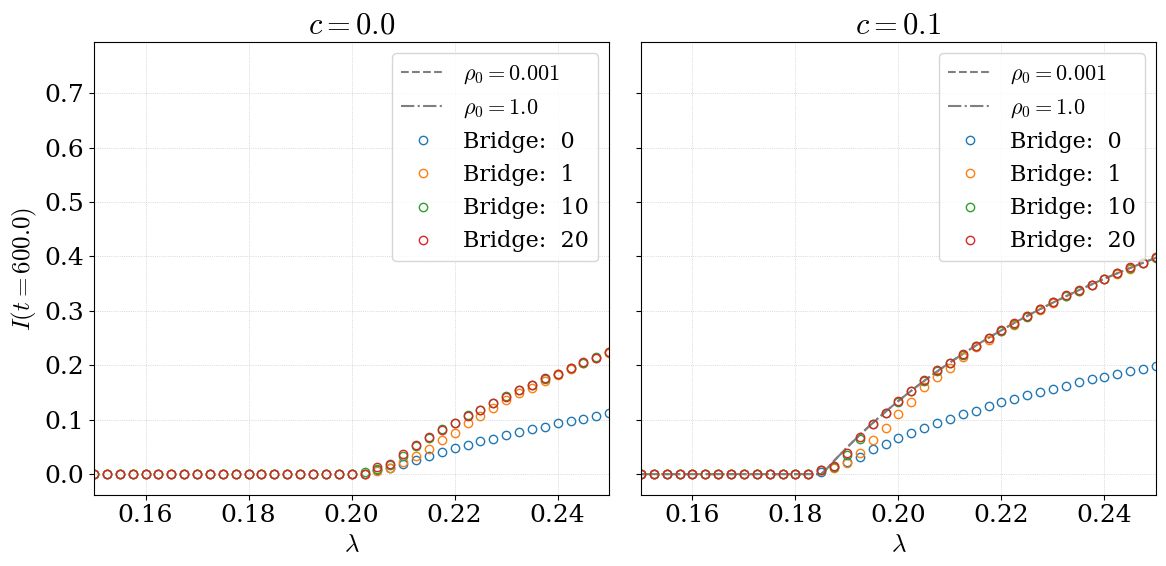

In [103]:
fig, axes = plt.subplots(1, len(c_list2), figsize=(6 * len(c_list2), 6), sharey=True)

for c_idx, c in enumerate(c_list_ame):
    axes[c_idx].plot(lambda_values_ame[0, c_idx], I_ame[0, c_idx], label=rf"$\rho_0=0.001$", linestyle="--", color=colors[-3])
    axes[c_idx].plot(lambda_values_ame[1, c_idx], I_ame[1, c_idx], label=rf"$\rho_0=1.0$", linestyle="-.", color=colors[-3])

for c_idx, c in enumerate(c_list):

    for e_idx in range(len(edgeNumList)):
        edge_num = edgeNumList[e_idx]
        valid_mean_I = valid_last_I[e_idx, c_idx, :]
        axes[c_idx].plot(lamb_values, valid_mean_I/(2 * N), label=rf"Bridge:  {edge_num}", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])
        # axes[c_idx].plot(lamb_values, valid_mean_I/(2 * N), label=f"edge={edge_num}", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])

    axes[c_idx].legend()
    axes[c_idx].grid(True, linestyle=":", alpha=0.5)
    axes[c_idx].set_title(rf"$c={c}$")
    axes[c_idx].set_xlabel(r"$\lambda$")
    if c_idx == 0:
        axes[c_idx].set_ylabel(rf"$I(t={tmax})$")
    # axes[c_idx].set_xlim(0.10, 0.11)
    axes[c_idx].set_xlim(min(lamb_values), max(lamb_values))
    # axes[c_idx].set_ylim(0-delta, 1+delta)

# fig.suptitle(rf"Network$: {network_type}, N={N}, \left<k\right>={k_ave}, \rho_0={rho0}, $tmax$={tmax}$")
fig.tight_layout()

plt.show()

In [104]:
output_path = os.path.abspath(os.path.join('..', 'output/sis/2RR/z=6/N=1000-c2.5'))
times_all25, infected_num_all25, axes25 = load(path=output_path)
meta25 = _read_metadata()
network_type25 = axes25["network_type"]
N25 = axes25["N"]
k_ave25 = axes25["k_ave"]
gamma25 = axes25["gamma"]
rho025 = axes25["rho0"]
tmax25 = axes25["tmax"]
seed25 = axes25["seed"]
total_itr25 = axes25["total_itr"]
c_list25 = axes25["c_list"]
edgeNumList25 = axes25["edgeNumList"]
lamb_values25 = axes25["lamb_values"]

idx: 0, 0th file is found
idx: 1, 1th file is found
idx: 2, 2th file is found
idx: 3, 3th file is found
idx: 4, 4th file is found
idx: 5, 5th file is found
idx: 6, 6th file is found
idx: 7, 7th file is found
idx: 8, 8th file is found
idx: 9, 9th file is found
idx: 10, 10th file is found
idx: 11, 11th file is found
idx: 12, 12th file is found
idx: 13, 13th file is found
idx: 14, 14th file is found
idx: 15, 15th file is found
idx: 16, 16th file is found
idx: 17, 17th file is found
idx: 18, 18th file is found
idx: 19, 19th file is found
idx: 20, 20th file is found
idx: 21, 21th file is found
idx: 22, 22th file is found
idx: 23, 23th file is found
idx: 24, 24th file is found
idx: 25, 25th file is found
idx: 26, 26th file is found
idx: 27, 27th file is found
idx: 28, 28th file is found
idx: 29, 29th file is found
idx: 30, 30th file is found
idx: 31, 31th file is found
idx: 32, 32th file is found
idx: 33, 33th file is found
idx: 34, 34th file is found
idx: 35, 35th file is found
idx: 36, 36t

In [105]:
print("==== shape ====")
print(times_all25.shape)
print(infected_num_all25.shape)

print("")
print("==== params ====")
print(f"network_type: {network_type25}")
print(f"N: {N25}")
print(f"k_ave: {k_ave25}")
print(f"gamma: {gamma25}")
print(f"rho0: {rho025}")
print(f"tmax: {tmax25}")
print(f"seed: {seed2}")
print(f"total_itr: {total_itr2}")

print("")
print("==== meta data ====")
for key, value in meta25.items():
    print(f"{key}: {value}")

==== shape ====
(4, 1, 61, 1000)
(4, 1, 61, 1000)

==== params ====
network_type: 2RR
N: 1000
k_ave: 6
gamma: 1.0
rho0: 0.5
tmax: 1000.0
seed: 0.0
total_itr: 200

==== meta data ====
start_time: 2025-09-13 02:54:11
end_time: 2025-09-13 04:13:48
duration_seconds: 4777.805
network_type: 2RR
runs_per_batch: 410
total_runs: 16400
seed_base: 0
os_name: Mac OS X
os_version: 15.3.1
java_version: 24.0.2
java_vendor: Homebrew
cpu_cores: 10
total_memory_mb: 3762
max_memory_mb: 4096


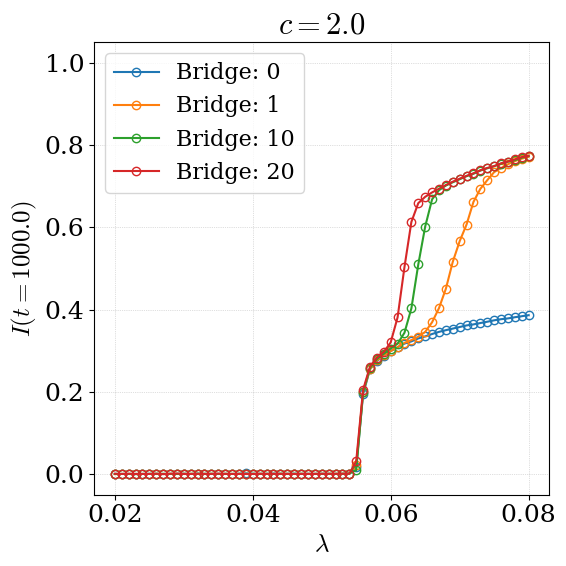

In [106]:
last_I25 = np.zeros((len(edgeNumList25), len(c_list25), len(lamb_values25), total_itr25))
valid_last_I25 = np.zeros((len(edgeNumList25), len(c_list25), len(lamb_values25)))
valid_num25 = np.zeros((len(edgeNumList25), len(c_list25), len(lamb_values25)))

for edge_idx in range(len(edgeNumList2)):
    for c_idx in range(len(c_list25)):
        for lamb_idx in range(len(lamb_values25)):
            valid = []
            non_valid = []
            for itr_idx in range(total_itr25):
                last_I25[edge_idx, c_idx, lamb_idx, itr_idx] = infected_num_all25[edge_idx, c_idx, lamb_idx, itr_idx][0]
                if last_I25[edge_idx, c_idx, lamb_idx, itr_idx] > threshold:
                    valid.append(last_I25[edge_idx, c_idx, lamb_idx, itr_idx])
                    valid_num25[edge_idx, c_idx, lamb_idx] += 1
                else:
                    non_valid.append(last_I25[edge_idx, c_idx, lamb_idx, itr_idx])
            if len(valid) > 0:
                valid_last_I25[edge_idx, c_idx, lamb_idx] = np.mean(valid)
            else:
                valid_last_I25[edge_idx, c_idx, lamb_idx] = np.mean(non_valid)


fig, axes = plt.subplots(1, len(c_list25), figsize=(6 * len(c_list25), 6), sharey=True, squeeze=False)

for c_idx, c in enumerate(c_list25):
    if len(c_list25) == 1:
        ax = axes[0, c_idx]
    else:
        ax = axes[c_idx]

    for e_idx in range(len(edgeNumList25)):
        edge_num = edgeNumList25[e_idx]
        valid_mean_I25 = valid_last_I25[e_idx, c_idx, :]
        ax.plot(lamb_values25, valid_mean_I25/(2 * N25), label=rf"Bridge: {edge_num}", linestyle="-", color=colors[e_idx], marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])
        # axes[c_idx].plot(lamb_values, valid_mean_I/(2 * N), label=f"edge={edge_num}", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])

    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_title(rf"$c={c}$")
    ax.set_xlabel(r"$\lambda$")
    if c_idx == 0:
        ax.set_ylabel(rf"$I(t={tmax25})$")
    # axes[c_idx].set_xlim(0.10, 0.11)
    ax.set_ylim(0-delta, 1+delta)

# fig.suptitle(rf"Network$: {network_type}, N={N}, \left<k\right>={k_ave}, \rho_0={rho0}, $tmax$={tmax}$")
fig.tight_layout()

plt.show()

In [107]:
rho0List_ame25 = [0.001, 1.0]
c_list_ame25 = [2.0]
arr25 = np.zeros((len(rho0List_ame25), len(c_list_ame25)), dtype=object)
lambda_values_ame25 = np.zeros((len(rho0List_ame25), len(c_list_ame25)), dtype=object)
I_ame25 = np.zeros((len(rho0List_ame25), len(c_list_ame25)), dtype=object)

base_ame_path = "../ame/"
for r_idx, rho0 in enumerate(rho0List_ame25):
    str_rho0 = str(rho0)
    for c_idx, c in enumerate(c_list_ame25):
        str_c = str(c)
        file = os.path.join(base_ame_path, "ame-rho" + str_rho0 + "-c" + str_c + ".dat")
        try:
            arr25[r_idx, c_idx] = np.genfromtxt(file, names=True)
            lambda_values_ame25[r_idx, c_idx] = np.array(arr25[r_idx, c_idx]["lambda0"])
            I_ame25[r_idx, c_idx] = np.array(arr25[r_idx, c_idx]["I"])
        except:
            print(f"Error: {file} not found")


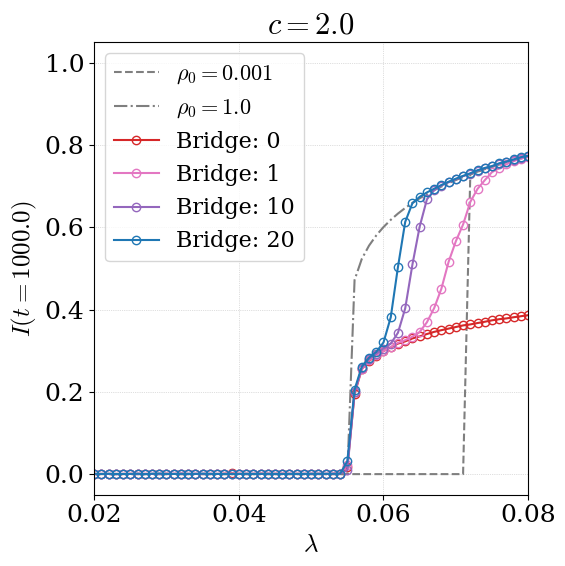

In [108]:
colors = ["tab:red", "tab:pink", "tab:purple", "tab:blue"]

fig, axes = plt.subplots(1, len(c_list25), figsize=(6 * len(c_list25), 6), sharey=True, squeeze=False)

for c_idx, c in enumerate(c_list25):
    if len(c_list25) == 1:
        ax = axes[0, c_idx]
    else:
        ax = axes[c_idx]

    ax.plot(lambda_values_ame25[0, c_idx], I_ame25[0, c_idx], label=rf"$\rho_0=0.001$", linestyle="--", color="tab:gray")
    ax.plot(lambda_values_ame25[1, c_idx], I_ame25[1, c_idx], label=rf"$\rho_0=1.0$", linestyle="-.", color="tab:gray")

    for e_idx in range(len(edgeNumList25)):
        edge_num = edgeNumList25[e_idx]
        valid_mean_I25 = valid_last_I25[e_idx, c_idx, :]
        ax.plot(lamb_values25, valid_mean_I25/(2 * N25), label=rf"Bridge: {edge_num}", linestyle="-", color=colors[e_idx], marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])
        # axes[c_idx].plot(lamb_values, valid_mean_I/(2 * N), label=f"edge={edge_num}", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])
    ax.legend()
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_title(rf"$c={c}$")
    ax.set_xlabel(r"$\lambda$")
    if c_idx == 0:
        ax.set_ylabel(rf"$I(t={tmax25})$")
    ax.set_xlim(min(lamb_values25), max(lamb_values25))
    ax.set_ylim(0-delta, 1+delta)

# fig.suptitle(rf"Network$: {network_type}, N={N}, \left<k\right>={k_ave}, \rho_0={rho0}, $tmax$={tmax}$")
fig.tight_layout()

plt.show()

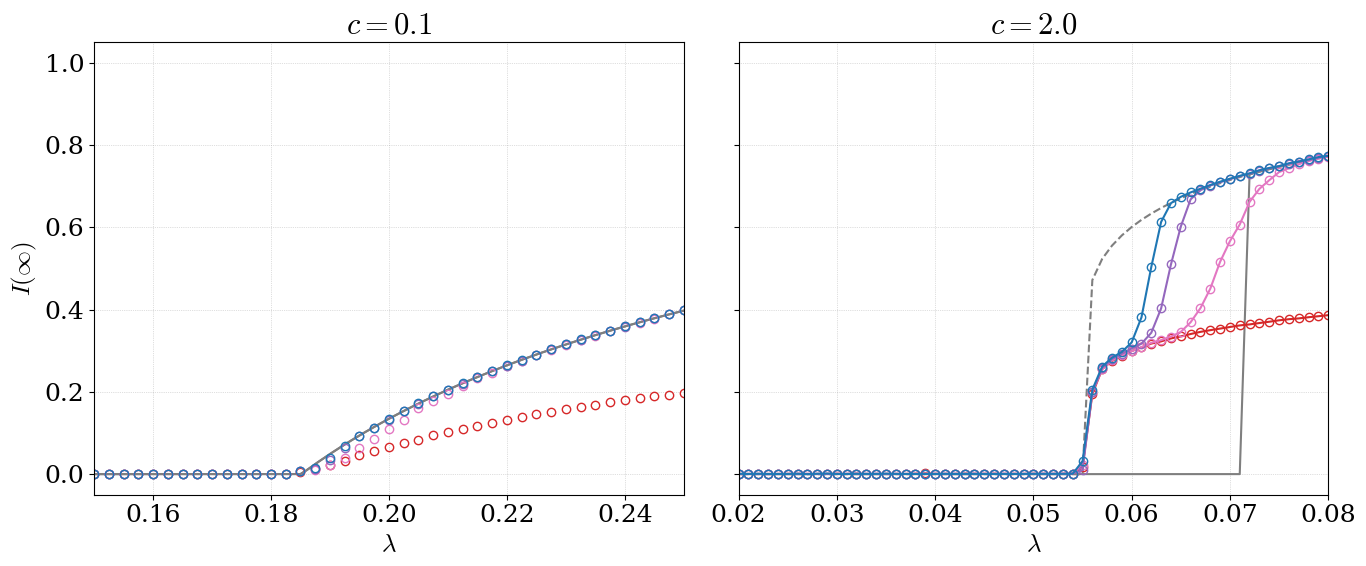

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(7 * len(c_list2), 6), sharey=True, squeeze=False)

beta_idx = 1
ax = axes[0, 0]
ax.plot(lambda_values_ame[0, beta_idx], I_ame[0, beta_idx], label=rf"$\rho_0=0.001$", linestyle="-", color="tab:gray")
ax.plot(lambda_values_ame[1, beta_idx], I_ame[1, beta_idx], label=rf"$\rho_0=1.0$", linestyle="-", color="tab:gray")

for e_idx in range(len(edgeNumList)):
    edge_num = edgeNumList[e_idx]
    valid_mean_I = valid_last_I[e_idx, beta_idx, :]
    ax.plot(lamb_values, valid_mean_I/(2 * N), label=rf"Bridge:  {edge_num}", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])
    # axes[0].plot(lamb_values, valid_mean_I/(2 * N), label=f"edge={edge_num}", linestyle="", marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])

# ax.legend()
ax.grid(True, linestyle=":", alpha=0.5)
ax.set_title(rf"$c={c_list[beta_idx]}$")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(rf"$I(\infty)$")
ax.set_xlim(min(lamb_values), max(lamb_values))

ax = axes[0, 1]
ax.plot(lambda_values_ame25[0, c_idx], I_ame25[0, c_idx], label=rf"$\rho_0=0.001$", linestyle="-", color="tab:gray")
ax.plot(lambda_values_ame25[1, c_idx], I_ame25[1, c_idx], label=rf"$\rho_0=1.0$", linestyle="--", color="tab:gray")

for e_idx in range(len(edgeNumList25)):
    edge_num = edgeNumList25[e_idx]
    valid_mean_I25 = valid_last_I25[e_idx, c_idx, :]
    ax.plot(lamb_values25, valid_mean_I25/(2 * N25), label=rf"Bridge: {edge_num}", linestyle="-", color=colors[e_idx], marker="o", markersize=6, markerfacecolor="none", markeredgecolor=colors[e_idx])

    # ax.legend()
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_title(rf"$c={c_list25[0]}$")
    ax.set_xlabel(r"$\lambda$")
    ax.set_xlim(min(lamb_values25), max(lamb_values25))
    ax.set_ylim(0-delta, 1+delta)

fig.tight_layout()

base = "fig.png"
suf = 0
while os.path.exists(base):
    suf += 1
    base = f"fig_{suf}.png"
plt.savefig(base, dpi=300)
plt.show()